In [1]:
from math import*
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import casadi
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.kernel_ridge import KernelRidge
import itertools
from scipy import stats
from sklearn.model_selection import train_test_split, KFold

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss
from sklearn.inspection import permutation_importance
from sklearn.neighbors import NearestNeighbors
from scipy.stats import spearmanr
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDClassifier
from sklearn.utils.validation import check_is_fitted

from ucimlrepo import fetch_ucirepo

from rkhs_glm_scaled import RKHSGLM_Scaled, sigmoid, KERNELS

from pseudo_label_experiment_general import FAMILIES, make_data, mean, KGLM_covariate_shift, a_logpartition, run_experiment

In [2]:
# Load the raisin dataset and preprocess it
  
# fetch dataset 
raisin = fetch_ucirepo(id=850) 
  
# data (as pandas dataframes) 
X = raisin.data.features 
y_tot = raisin.data.targets 

# Convert to numpy arrays
x_tot = X.to_numpy()
y_tot = y_tot.to_numpy().ravel()

# Binary encode y
y_tot = np.where(y_tot == 'Kecimen', 1, 0)

# Scale the data
x_tot=(x_tot-x_tot.mean(axis=0))/x_tot.std(axis=0)
n=y_tot.shape[0]

y_tot=y_tot.astype(np.double)

# Utils

In [3]:
def evaluate_binary(y_true, p, thr=0.5, prefix=""):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p)
    yhat = (p >= thr).astype(int)
    out = {
        f"{prefix}acc": accuracy_score(y_true, yhat),
        f"{prefix}bal_acc": balanced_accuracy_score(y_true, yhat),
        f"{prefix}auc": roc_auc_score(y_true, p),
        f"{prefix}logloss": log_loss(y_true, p),
        f"{prefix}pos_rate": float(np.mean(y_true))
    }
    return out

def pretty_print_metrics(m):
    keys = list(m.keys())
    maxk = max(len(k) for k in keys)
    for k in sorted(keys):
        v = m[k]
        if isinstance(v, float):
            print(f"{k:<{maxk}} : {v:.4f}")
        else:
            print(f"{k:<{maxk}} : {v}")

    
def _sigmoid(z):
    z = np.asarray(z)
    return 1.0 / (1.0 + np.exp(-z))

def _soft_logistic_risk_from_f(alog, f, p_soft_or_y):
    """
    risk = E[ alog(f) - y f ] where y can be hard {0,1} or soft in [0,1].
    """
    return float(np.mean(alog(f) - p_soft_or_y * f))

def _metrics_from_scores(y_true, f, compute_auc=True):
    """
    Given true labels y and decision scores f, compute:
    acc, bal_acc, risk (caller computed), auc/logloss if requested.
    """
    y_true = y_true.astype(int)
    p = _sigmoid(f)
    y_pred = (p >= 0.5).astype(int)

    out = {
        "acc": float(accuracy_score(y_true, y_pred)),
        "bal_acc": float(balanced_accuracy_score(y_true, y_pred)),
    }
    if compute_auc:
        # AUC undefined if only one class in y_true
        if np.all(y_true == y_true[0]):
            out["auc"] = np.nan
            out["logloss_sklearn"] = np.nan
        else:
            out["auc"] = float(roc_auc_score(y_true, p))
            out["logloss_sklearn"] = float(log_loss(y_true, np.clip(p, 1e-15, 1 - 1e-15)))
    return out

In [4]:
# ID / OOD split

def split_id_ood(x, y, le=3, seed=1):
    n=y.shape[0]
    rng = np.random.default_rng(seed)
    p=(x[:,0]-x[:,0].min())**2/le
    p=np.clip(p,a_max=1,a_min=0)


    # Splitting into training data and test data
    x_train=[]
    y_train=[]
    x_test=[]
    y_test=[]

    s = rng.binomial(1,p,p.shape[0])
    for k in range(n):
        if s[k]==0:
            x_train.append(x[k,:])
            y_train.append(y[k])
        else:
            x_test.append(x[k,:])
            y_test.append(y[k])

    x_train=np.array(x_train)
    y_train=np.array(y_train)

    x_test=np.array(x_test)
    y_test=np.array(y_test)

    return x_train, y_train, x_test, y_test

In [5]:
# Main class

class sk_log_covariate_shift:
    """
    Two modes:

    - mode="practical" (default):
        OOD split -> cross-fit on ID (K-fold + repeats) -> select lambdas ->
        refit final models on all ID -> evaluate on OOD_test.

    - mode="theory":
        OOD split -> single holdout split of ID into X1 (candidates) / X2 (imputer+naive eval) ->
        compute risk curves on that split -> select lambdas ->
        NO refit: final models are the candidates trained on X1 with selected lambdas ->
        evaluate on OOD_test.

    Inputs:
      - ID: (X, y) labeled source
      - OOD: (X0, y0) labeled target (y0 only used for oracle selection on OOD_sel and for final eval on OOD_test)
    """

    def __init__(self, X, y, X0, y0, family, seed, **kwargs):
        self.outer_seed = int(seed)
        self.family = family
        self.alog = lambda theta: a_logpartition(theta, family, **kwargs)

        self.X = np.asarray(X)
        self.y = np.asarray(y).astype(int)

        self.X_0 = np.asarray(X0)
        self.y_0 = np.asarray(y0).astype(int)

        self.n = self.X.shape[0]
        self.n_0 = self.X_0.shape[0]

    def _make_lambda_grid(self, beta=2.0, lbd_min=1e-4, lbd_max=100.0):
        assert beta > 1
        m = int(np.ceil(np.log(lbd_max / lbd_min) / np.log(beta))) + 1
        return lbd_min * (beta ** np.arange(m))

    def _fit_logreg(self, Xtr, ytr, lbd):
        return LogisticRegression(max_iter=5000, C=1.0 / float(lbd)).fit(Xtr, ytr)

    def _outer_split_ood(self, ood_test_frac):
        sss = StratifiedShuffleSplit(
            n_splits=1,
            test_size=ood_test_frac,
            random_state=self.outer_seed
        )
        (idx_sel, idx_test), = sss.split(self.X_0, self.y_0)

        self.X0_test = self.X_0[idx_test]
        self.y0_test = self.y_0[idx_test]
        self.X0_sel  = self.X_0[idx_sel]
        self.y0_sel  = self.y_0[idx_sel]

    def _fit_mode_practical(
        self,
        n_splits,
        repeats,
        lbd_tilde,
        compute_auc
    ):
        """
        Your current cross-fit + refit-on-all-ID workflow.
        """

        mL = len(self.Lambda)
        err_naive_sum  = np.zeros(mL)
        err_pseudo_sum = np.zeros(mL)
        err_oracle_sum = np.zeros(mL)
        count = 0

        base_kf_seed = 10_000 + self.outer_seed

        for r in range(int(repeats)):
            kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=base_kf_seed + r)

            for (train_idx, val_idx) in kf.split(self.X, self.y):
                idx_imp  = train_idx
                idx_cand = val_idx

                X_imp, y_imp     = self.X[idx_imp],  self.y[idx_imp]
                X_cand, y_cand   = self.X[idx_cand], self.y[idx_cand]

                imp = self._fit_logreg(X_imp, y_imp, lbd=lbd_tilde)
                p_soft_sel = imp.predict_proba(self.X0_sel)[:, 1]

                fold_naive  = np.zeros(mL)
                fold_pseudo = np.zeros(mL)
                fold_oracle = np.zeros(mL)

                for j, lbd in enumerate(self.Lambda):
                    cand = self._fit_logreg(X_cand, y_cand, lbd=lbd)

                    f_imp = cand.decision_function(X_imp)
                    fold_naive[j] = _soft_logistic_risk_from_f(self.alog, f_imp, y_imp)

                    f_sel = cand.decision_function(self.X0_sel)
                    fold_pseudo[j] = _soft_logistic_risk_from_f(self.alog, f_sel, p_soft_sel)
                    fold_oracle[j] = _soft_logistic_risk_from_f(self.alog, f_sel, self.y0_sel)

                err_naive_sum  += fold_naive
                err_pseudo_sum += fold_pseudo
                err_oracle_sum += fold_oracle
                count += 1

        self.err_est_naive  = err_naive_sum  / count
        self.err_est_pseudo = err_pseudo_sum / count
        self.err_est_real   = err_oracle_sum / count

        # selections
        self.j_naive  = int(np.argmin(self.err_est_naive))
        self.j_pseudo = int(np.argmin(self.err_est_pseudo))
        self.j_real   = int(np.argmin(self.err_est_real))

        self.lbd_naive  = float(self.Lambda[self.j_naive])
        self.lbd_pseudo = float(self.Lambda[self.j_pseudo])
        self.lbd_real   = float(self.Lambda[self.j_real])

        # refit final models on ALL ID (practical)
        self.model_naive  = self._fit_logreg(self.X, self.y, self.lbd_naive)
        self.model_pseudo = self._fit_logreg(self.X, self.y, self.lbd_pseudo)
        self.model_real   = self._fit_logreg(self.X, self.y, self.lbd_real)

        # candidates on all ID (for test-risk curve/regret diagnostics)
        self.model = [self._fit_logreg(self.X, self.y, lbd) for lbd in self.Lambda]

        # optional imputer on all ID
        self.model_tilde = self._fit_logreg(self.X, self.y, lbd=lbd_tilde)

        # evaluate
        self.eval_out = self.evaluate_final(compute_auc=compute_auc)
        return self

    def _fit_mode_theory(
        self,
        id_holdout_frac,
        stratify_id,
        lbd_tilde,
        compute_auc
    ):
        """
        Theory-like:
          - one split ID -> X1 (candidates) and X2 (imputer + naive validation)
          - select lambdas using that single split
          - NO refit: final models are candidates trained on X1
        """

        # 1) single ID split into X1/X2
        X1, X2, y1, y2 = train_test_split(
            self.X, self.y,
            test_size=float(id_holdout_frac),
            random_state=self.outer_seed,
            stratify=self.y if stratify_id else None
        )
        self.X1, self.y1 = X1, y1
        self.X2, self.y2 = X2, y2

        # 2) imputer trained on X2
        imp = self._fit_logreg(X2, y2, lbd=lbd_tilde)
        p_soft_sel = imp.predict_proba(self.X0_sel)[:, 1]
        self.model_tilde = imp  # imputer in theory-mode is the X2 one

        # 3) train all candidates on X1 once, store them
        self.model_X1 = [self._fit_logreg(X1, y1, lbd) for lbd in self.Lambda]

        # 4) compute selection risks on this holdout construction
        mL = len(self.Lambda)
        err_naive  = np.zeros(mL)
        err_pseudo = np.zeros(mL)
        err_oracle = np.zeros(mL)

        for j, cand in enumerate(self.model_X1):
            # naive: evaluate on X2 (labeled ID holdout)
            f2 = cand.decision_function(X2)
            err_naive[j] = _soft_logistic_risk_from_f(self.alog, f2, y2)

            # pseudo/oracle: evaluate on OOD_sel
            f_sel = cand.decision_function(self.X0_sel)
            err_pseudo[j] = _soft_logistic_risk_from_f(self.alog, f_sel, p_soft_sel)
            err_oracle[j] = _soft_logistic_risk_from_f(self.alog, f_sel, self.y0_sel)

        self.err_est_naive  = err_naive
        self.err_est_pseudo = err_pseudo
        self.err_est_real   = err_oracle

        # 5) select lambdas
        self.j_naive  = int(np.argmin(self.err_est_naive))
        self.j_pseudo = int(np.argmin(self.err_est_pseudo))
        self.j_real   = int(np.argmin(self.err_est_real))

        self.lbd_naive  = float(self.Lambda[self.j_naive])
        self.lbd_pseudo = float(self.Lambda[self.j_pseudo])
        self.lbd_real   = float(self.Lambda[self.j_real])

        # 6) NO refit: choose final models from candidates trained on X1
        self.model_naive  = self.model_X1[self.j_naive]
        self.model_pseudo = self.model_X1[self.j_pseudo]
        self.model_real   = self.model_X1[self.j_real]

        # for regret/test-risk curve, "candidate family" should match what selection had access to
        self.model = self.model_X1

        # evaluate
        self.eval_out = self.evaluate_final(compute_auc=compute_auc)
        return self

    def fit(
        self,
        mode="practical",
        # common
        beta=2.0,
        lbd_min=1e-4,
        lbd_max=100.0,
        lbd_tilde=1e-4,
        ood_test_frac=0.35,
        compute_auc=True,
        # practical-only
        n_splits=5,
        repeats=1,
        # theory-only
        id_holdout_frac=0.50,
        stratify_id=True,
    ):
        """
        mode:
          - "practical": cross-fit on ID + refit on full ID
          - "theory": single holdout split X1/X2 on ID + no refit

        ood_test_frac:
          fraction of OOD used for evaluation; remainder used for model selection (OOD_sel)
        id_holdout_frac (theory):
          fraction of ID used as X2 (imputer + naive validation); remainder is X1 (candidates)
        """

        mode = str(mode).lower()
        if mode not in {"practical", "theory"}:
            raise ValueError("mode must be 'practical' or 'theory'.")

        # 0) lambda grid
        self.Lambda = self._make_lambda_grid(beta=beta, lbd_min=lbd_min, lbd_max=lbd_max)

        # 1) outer OOD split
        self._outer_split_ood(ood_test_frac=ood_test_frac)

        # 2-4) mode-specific
        if mode == "practical":
            if n_splits < 2:
                raise ValueError("n_splits must be >= 2 for practical (cross-fit) mode.")
            return self._fit_mode_practical(
                n_splits=n_splits,
                repeats=repeats,
                lbd_tilde=lbd_tilde,
                compute_auc=compute_auc
            )

        # theory
        return self._fit_mode_theory(
            id_holdout_frac=id_holdout_frac,
            stratify_id=stratify_id,
            lbd_tilde=lbd_tilde,
            compute_auc=compute_auc
        )

    def evaluate_final(self, compute_auc=True):
        """
        Point evaluation on OOD_test ONLY (no bootstrap).
        """
        y = self.y0_test.astype(int)

        f_naive  = self.model_naive.decision_function(self.X0_test)
        f_pseudo = self.model_pseudo.decision_function(self.X0_test)
        f_oracle = self.model_real.decision_function(self.X0_test)

        loss_naive  = self.alog(f_naive)  - y * f_naive
        loss_pseudo = self.alog(f_pseudo) - y * f_pseudo
        loss_oracle = self.alog(f_oracle) - y * f_oracle

        out = {}
        out["naive"]  = _metrics_from_scores(y, f_naive,  compute_auc=compute_auc)
        out["pseudo"] = _metrics_from_scores(y, f_pseudo, compute_auc=compute_auc)
        out["oracle"] = _metrics_from_scores(y, f_oracle, compute_auc=compute_auc)

        out["naive"]["risk"]  = float(np.mean(loss_naive))
        out["pseudo"]["risk"] = float(np.mean(loss_pseudo))
        out["oracle"]["risk"] = float(np.mean(loss_oracle))

        out["naive"]["risk_se_plugin"]  = float(np.std(loss_naive,  ddof=1) / np.sqrt(len(loss_naive)))
        out["pseudo"]["risk_se_plugin"] = float(np.std(loss_pseudo, ddof=1) / np.sqrt(len(loss_pseudo)))
        out["oracle"]["risk_se_plugin"] = float(np.std(loss_oracle, ddof=1) / np.sqrt(len(loss_oracle)))

        diff_pn = (loss_pseudo - loss_naive)
        out["diff_pseudo_minus_naive"] = {
            "risk": float(np.mean(diff_pn)),
            "risk_se_plugin": float(np.std(diff_pn, ddof=1) / np.sqrt(len(diff_pn))),
        }

        out["selected_lambdas"] = {
            "naive":  getattr(self, "lbd_naive",  np.nan),
            "pseudo": getattr(self, "lbd_pseudo", np.nan),
            "oracle": getattr(self, "lbd_real",   np.nan),
        }
        out["selection_indices"] = {
            "j_naive":  getattr(self, "j_naive",  None),
            "j_pseudo": getattr(self, "j_pseudo", None),
            "j_oracle": getattr(self, "j_real",   None),
        }
        out["ood_sizes"] = {
            "n_ood_sel": int(self.X0_sel.shape[0]),
            "n_ood_test": int(self.X0_test.shape[0]),
        }
        if hasattr(self, "X2"):
            out["id_sizes"] = {
                "n_X1": int(self.X1.shape[0]),
                "n_X2": int(self.X2.shape[0]),
            }
        return out

    def report_selection_summary(self, digits=4):
        """
        Minimal console summary (no bootstrap).
        """
        def fmt(x):
            if x is None or (isinstance(x, float) and np.isnan(x)):
                return "NA"
            return f"{x:.{digits}f}"

        print("\n=== OOD split sizes ===")
        print("OOD_sel :", self.X0_sel.shape[0])
        print("OOD_test:", self.X0_test.shape[0])

        if hasattr(self, "X2"):
            print("\n=== ID holdout split sizes (theory mode) ===")
            print("X1 (candidates):", self.X1.shape[0])
            print("X2 (imputer/valid):", self.X2.shape[0])

        print("\n=== Selected lambdas ===")
        print("Naive :", self.lbd_naive)
        print("Pseudo:", self.lbd_pseudo)
        print("Oracle:", self.lbd_real)

        print("\n=== OOD_test point estimates ===")
        for key in ["naive", "pseudo", "oracle"]:
            d = self.eval_out[key]
            line = f"{key:>6} | risk={fmt(d['risk'])}  acc={fmt(d['acc'])}  bal_acc={fmt(d['bal_acc'])}"
            if "auc" in d:
                line += f"  auc={fmt(d.get('auc'))}  logloss={fmt(d.get('logloss_sklearn'))}"
            print(line)

        return self.eval_out


In [6]:
"""
Experiment runner for covariate shift on Raisin (or any tabular binary dataset).

Assumptions:
- You have a class: sk_log_covariate_shift(X_id, y_id, X_ood, y_ood, family, seed, **kwargs)
  with methods:
    - fit(**fit_kwargs)  # should produce selections + evaluation on OOD_test
  and attributes after fit:
    - eval_out[method][metric]  (method in {"naive","pseudo","oracle"})
      metrics include: "risk", and optionally "acc","bal_acc","auc","logloss_sklearn"
    - Lambda (grid, shape mL)
    - err_est_naive, err_est_pseudo, err_est_real (selection curves, shape mL)
    - lbd_naive, lbd_pseudo, lbd_real
    - j_naive, j_pseudo, j_real
    - model (list of candidate models fit on ID, length mL)
    - Xtestout, ytestout (OOD_test)
    - alog callable (log-partition)
- You have a splitter: split_id_ood(x_tot, y_tot, le=3, seed=seed)
  returning either:
    (X_id, y_id, X_ood, y_ood)
  OR
    (X_id, y_id, X_ood, y_ood, extra...)
"""


# ----------------------------
# Core stats helpers
# ----------------------------
def _t_ci_mean(arr, alpha=0.05):
    arr = np.asarray(arr, float)
    arr = arr[np.isfinite(arr)]
    n = len(arr)
    m = float(arr.mean())
    s = float(arr.std(ddof=1))
    se = s / np.sqrt(n)
    tcrit = stats.t.ppf(1 - alpha/2, df=n-1)
    return m, (m - tcrit*se, m + tcrit*se), se

def _paired_diff(A, B):
    A = np.asarray(A, float)
    B = np.asarray(B, float)
    mask = np.isfinite(A) & np.isfinite(B)
    return A[mask] - B[mask]

def paired_tests(diffs, name, alternative="less", alpha=0.05, B=20000, boot_seed=0):
    """
    diffs: per-seed paired differences (A - B) for metric.
    alternative:
      - "less" means H1: mean(diffs) < 0 (A better if lower is better)
      - "greater" means H1: mean(diffs) > 0
      - "two-sided"
    """
    diffs = np.asarray(diffs, float)
    diffs = diffs[np.isfinite(diffs)]
    S = len(diffs)
    if S < 5:
        raise ValueError(f"Too few seeds after filtering: {S}")

    mean_diff = float(diffs.mean())
    sd = float(diffs.std(ddof=1))
    se = sd / np.sqrt(S)
    t_stat, p_two = stats.ttest_1samp(diffs, 0.0)

    if alternative == "two-sided":
        p_t = float(p_two)
    elif alternative == "less":
        p_t = float(p_two/2) if t_stat < 0 else float(1 - p_two/2)
    elif alternative == "greater":
        p_t = float(p_two/2) if t_stat > 0 else float(1 - p_two/2)
    else:
        raise ValueError("alternative must be one of {'less','greater','two-sided'}")

    tcrit = stats.t.ppf(1 - alpha/2, df=S-1)
    ci_t = (mean_diff - tcrit*se, mean_diff + tcrit*se)

    # Wilcoxon signed-rank
    try:
        w_stat, p_w = stats.wilcoxon(diffs, alternative=alternative, zero_method="wilcox")
        w_stat, p_w = float(w_stat), float(p_w)
    except Exception:
        w_stat, p_w = np.nan, np.nan

    # Sign test
    eps = 1e-12
    if alternative == "less":
        wins = int(np.sum(diffs < -eps))
        ties = int(np.sum(np.abs(diffs) <= eps))
        n_eff = int(S - ties)
        p_sign = float(stats.binomtest(wins, n_eff, p=0.5, alternative="greater").pvalue) if n_eff > 0 else np.nan
    elif alternative == "greater":
        wins = int(np.sum(diffs > eps))
        ties = int(np.sum(np.abs(diffs) <= eps))
        n_eff = int(S - ties)
        p_sign = float(stats.binomtest(wins, n_eff, p=0.5, alternative="greater").pvalue) if n_eff > 0 else np.nan
    else:
        wins = int(np.sum(diffs < -eps))
        ties = int(np.sum(np.abs(diffs) <= eps))
        n_eff = int(S - ties)
        p_sign = float(stats.binomtest(wins, n_eff, p=0.5, alternative="two-sided").pvalue) if n_eff > 0 else np.nan

    # Bootstrap CI over seeds
    rng = np.random.default_rng(boot_seed)
    boot_means = np.empty(B, float)
    for b in range(B):
        bs = rng.integers(0, S, size=S)
        boot_means[b] = diffs[bs].mean()
    ci_boot = (float(np.quantile(boot_means, alpha/2)), float(np.quantile(boot_means, 1-alpha/2)))
    if alternative == "less":
        p_boot = float(np.mean(boot_means >= 0.0))
    elif alternative == "greater":
        p_boot = float(np.mean(boot_means <= 0.0))
    else:
        p_boot = float(2 * min(np.mean(boot_means <= 0.0), np.mean(boot_means >= 0.0)))

    return {
        "name": name,
        "n_seeds": S,
        "mean": mean_diff,
        "sd": sd,
        "se": se,
        "ci_t": tuple(map(float, ci_t)),
        "t": float(t_stat),
        "p_t": float(p_t),
        "w": float(w_stat),
        "p_w": float(p_w),
        "wins": wins,
        "losses": int(S - ties - wins),
        "ties": ties,
        "p_sign": float(p_sign),
        "ci_boot": ci_boot,
        "p_boot": float(p_boot),
    }

def print_paired_test(res, digits=6):
    lo, hi = res["ci_t"]
    blo, bhi = res["ci_boot"]
    print(f"\n=== {res['name']} ===")
    print(f"n_seeds = {res['n_seeds']}")
    print(f"mean(A-B) = {res['mean']:.{digits}g}   sd = {res['sd']:.{digits}g}   se = {res['se']:.{digits}g}")
    print(f"95% t-CI for mean: [{lo:.{digits}g}, {hi:.{digits}g}]")
    print(f"t-test: t={res['t']:.{digits}g}, p={res['p_t']:.{digits}g}")
    print(f"Wilcoxon: W={res['w']:.{digits}g}, p={res['p_w']:.{digits}g}")
    print(f"Sign test: wins/losses/ties = {res['wins']}/{res['losses']}/{res['ties']}  p={res['p_sign']:.{digits}g}")
    print(f"Bootstrap CI (mean): [{blo:.{digits}g}, {bhi:.{digits}g}]  p={res['p_boot']:.{digits}g}")

def summarize_distribution(diffs, name):
    diffs = np.asarray(diffs, float)
    diffs = diffs[np.isfinite(diffs)]
    q = np.quantile(diffs, [0.10, 0.25, 0.50, 0.75, 0.90])
    eps = 1e-12
    wins = int(np.sum(diffs < -eps))
    losses = int(np.sum(diffs > eps))
    ties = int(np.sum(np.abs(diffs) <= eps))
    print(f"\n{name}")
    print(f" mean  : {diffs.mean()}")
    print(f" median: {np.median(diffs)}")
    print(f" 10/25/50/75/90%: {q}")
    print(f" wins/losses/ties: {wins}/{losses}/{ties} (wins fraction among non-ties: {wins/(wins+losses+1e-12):.3f})")


# ----------------------------
# Shift diagnostics (per seed)
# ----------------------------
def domain_clf_auc(X_id, X_ood, seed):
    """
    Domain classifier AUC: how separable ID vs OOD covariates are.
    Higher => bigger covariate shift.
    """
    X_id = np.asarray(X_id)
    X_ood = np.asarray(X_ood)
    X = np.vstack([X_id, X_ood])
    y = np.concatenate([np.zeros(len(X_id), int), np.ones(len(X_ood), int)])
    # simple logistic domain classifier
    clf = LogisticRegression(max_iter=5000, random_state=seed)
    clf.fit(X, y)
    p = clf.predict_proba(X)[:, 1]
    return float(roc_auc_score(y, p))

def smd_per_feature(X_id, X_ood):
    """
    Standardized mean difference per feature.
    """
    X_id = np.asarray(X_id, float)
    X_ood = np.asarray(X_ood, float)
    mu1 = X_id.mean(axis=0)
    mu0 = X_ood.mean(axis=0)
    v1 = X_id.var(axis=0, ddof=1)
    v0 = X_ood.var(axis=0, ddof=1)
    denom = np.sqrt(0.5*(v1+v0) + 1e-12)
    return (mu1 - mu0) / denom


# ----------------------------
# Regret on OOD_test (best-in-grid) using labels only
# ----------------------------
def test_risk_curve(exp):
    y = exp.y0_test.astype(int)
    risks = []
    for mdl in exp.model:
        f = mdl.decision_function(exp.X0_test)
        risks.append(np.mean(exp.alog(f) - y*f))
    return np.asarray(risks, float)

def regrets_best_in_grid(exp):
    rtest = test_risk_curve(exp)
    j_star = int(np.argmin(rtest))
    return {
        "min_test_risk": float(rtest[j_star]),
        "regret_naive": float(rtest[exp.j_naive] - rtest[j_star]),
        "regret_pseudo": float(rtest[exp.j_pseudo] - rtest[j_star]),
        "regret_oracle": float(rtest[exp.j_real] - rtest[j_star]),
        "j_star": j_star,
    }


# ----------------------------
# Runner: seeds -> collected results
# ----------------------------
def run_seeds_for_paper(x_tot, y_tot, seeds,
                        split_id_ood,
                        split_kwargs=None,
                        family="logistic",
                        family_kwargs=None,
                        fit_kwargs=None,
                        want_regret=True,
                        want_shift_diag=True):
    if split_kwargs is None:
        split_kwargs = {}
    if family_kwargs is None:
        family_kwargs = {}
    if fit_kwargs is None:
        fit_kwargs = {}

    methods = ["naive", "pseudo", "oracle"]
    # Candidate metrics we might collect (only keep those present in eval_out)
    candidate_metrics = ["risk", "acc", "bal_acc", "auc", "logloss_sklearn"]

    metrics = {meth: {met: [] for met in candidate_metrics} for meth in methods}
    lbd_sel = {meth: [] for meth in methods}
    curves = {meth: [] for meth in methods}  # selection curves
    Lambda_grid = None

    # shift diagnostics
    dom_auc = []
    smd_abs_mean = []  # mean absolute SMD across features per seed
    smd_abs_max = []   # max absolute SMD per seed

    # regrets
    regrets = {"min_test_risk": [], "regret_naive": [], "regret_pseudo": [], "regret_oracle": []}

    for s in seeds:
        out = split_id_ood(x_tot, y_tot, seed=s, **split_kwargs)
        if len(out) < 4:
            raise ValueError("split_id_ood must return at least (X_id,y_id,X_ood,y_ood).")
        X_id, y_id, X_ood, y_ood = out[:4]

        if want_shift_diag:
            dom_auc.append(domain_clf_auc(X_id, X_ood, seed=s))
            smd = smd_per_feature(X_id, X_ood)
            smd_abs_mean.append(float(np.mean(np.abs(smd))))
            smd_abs_max.append(float(np.max(np.abs(smd))))

        exp = sk_log_covariate_shift(X_id, y_id, X_ood, y_ood, family=family, seed=s, **family_kwargs)
        exp.fit(**fit_kwargs)

        # metrics from eval_out
        for meth in methods:
            if meth not in exp.eval_out:
                raise ValueError(f"exp.eval_out missing method '{meth}'. Found keys: {list(exp.eval_out.keys())}")
            for met in candidate_metrics:
                if met in exp.eval_out[meth]:
                    metrics[meth][met].append(exp.eval_out[meth][met])

        # selection curves and lambdas
        curves["naive"].append(exp.err_est_naive.copy())
        curves["pseudo"].append(exp.err_est_pseudo.copy())
        curves["oracle"].append(exp.err_est_real.copy())

        lbd_sel["naive"].append(exp.lbd_naive)
        lbd_sel["pseudo"].append(exp.lbd_pseudo)
        lbd_sel["oracle"].append(exp.lbd_real)

        if Lambda_grid is None:
            Lambda_grid = exp.Lambda.copy()
        else:
            if len(Lambda_grid) != len(exp.Lambda) or np.max(np.abs(Lambda_grid - exp.Lambda)) > 1e-12:
                raise ValueError("Lambda grid differs across seeds. Fix lbd_min/lbd_max/beta in fit_kwargs.")

        # regrets
        if want_regret:
            rg = regrets_best_in_grid(exp)
            for k in regrets:
                regrets[k].append(rg[k])

    # finalize arrays
    metrics = {meth: {met: np.asarray(vals, float)
                      for met, vals in md.items() if len(vals) > 0}
               for meth, md in metrics.items()}

    curves = {k: np.asarray(v, float) for k, v in curves.items()}
    lbd_sel = {k: np.asarray(v, float) for k, v in lbd_sel.items()}

    results = {
        "seeds": np.asarray(list(seeds), int),
        "metrics": metrics,
        "curves": curves,
        "Lambda_grid": np.asarray(Lambda_grid, float),
        "lambdas_selected": lbd_sel,
        "shift": {
            "domain_auc": np.asarray(dom_auc, float) if want_shift_diag else None,
            "smd_abs_mean": np.asarray(smd_abs_mean, float) if want_shift_diag else None,
            "smd_abs_max": np.asarray(smd_abs_max, float) if want_shift_diag else None,
        },
        "regrets": {k: np.asarray(v, float) for k, v in regrets.items()} if want_regret else None,
    }
    return results


# ----------------------------
# Paper comparisons + plots
# ----------------------------
def compare_all_pairs(results, metric, higher_is_better=False, alpha=0.05, B=20000):
    """
    Prints per-method mean+CI, then paired tests for:
      pseudo - naive, oracle - naive, pseudo - oracle
    """
    M = results["metrics"]
    methods = ["naive", "pseudo", "oracle"]
    if metric not in M["naive"]:
        raise ValueError(f"Metric '{metric}' not found. Available: {sorted(M['naive'].keys())}")

    print(f"\n=== Per-method '{metric}' across seeds: mean (95% CI) ===")
    for meth in methods:
        arr = M[meth][metric]
        m, ci, se = _t_ci_mean(arr, alpha=alpha)
        print(f"{meth:>6}: {m:.6f}  CI[{ci[0]:.6f}, {ci[1]:.6f}]  (SE={se:.6f})")

    # set alternative direction for paired tests
    # We always form diffs = A - B. If higher is better, "better" means mean(diffs) > 0 => alternative="greater".
    alt = "greater" if higher_is_better else "less"

    diffs_pn = _paired_diff(M["pseudo"][metric], M["naive"][metric])
    diffs_on = _paired_diff(M["oracle"][metric], M["naive"][metric])
    diffs_po = _paired_diff(M["pseudo"][metric], M["oracle"][metric])

    res_pn = paired_tests(diffs_pn, f"{metric}: pseudo - naive (H1: pseudo better)", alternative=alt, alpha=alpha, B=B, boot_seed=0)
    res_on = paired_tests(diffs_on, f"{metric}: oracle - naive (H1: oracle better)", alternative=alt, alpha=alpha, B=B, boot_seed=1)
    res_po = paired_tests(diffs_po, f"{metric}: pseudo - oracle (H1: pseudo better)", alternative=alt, alpha=alpha, B=B, boot_seed=2)

    print_paired_test(res_pn)
    print_paired_test(res_on)
    print_paired_test(res_po)

    summarize_distribution(diffs_pn, f"\n{metric} pseudo - naive distribution")
    summarize_distribution(diffs_on, f"\n{metric} oracle - naive distribution")
    summarize_distribution(diffs_po, f"\n{metric} pseudo - oracle distribution")

    return {"pseudo-naive": res_pn, "oracle-naive": res_on, "pseudo-oracle": res_po}


def plot_method_bars(results, metric, higher_is_better=False, alpha=0.05, title=None):
    M = results["metrics"]
    methods = ["naive", "pseudo", "oracle"]
    means, lo, hi = [], [], []
    for meth in methods:
        m, ci, _ = _t_ci_mean(M[meth][metric], alpha=alpha)
        means.append(m); lo.append(ci[0]); hi.append(ci[1])
    means = np.array(means)
    yerr = np.vstack([means - np.array(lo), np.array(hi) - means])

    plt.figure(figsize=(6,4))
    x = np.arange(len(methods))
    plt.bar(x, means)
    plt.errorbar(x, means, yerr=yerr, fmt="none", capsize=6)
    plt.xticks(x, methods)
    plt.ylabel(metric)
    ttl = title or f"{metric} (mean across seeds, {int((1-alpha)*100)}% CI)"
    plt.title(ttl)
    plt.tight_layout()
    plt.show()


def plot_diff_boxplots(results, metric, higher_is_better=False):
    M = results["metrics"]
    alt = "greater" if higher_is_better else "less"  # not used, but keeps semantics
    d_pn = _paired_diff(M["pseudo"][metric], M["naive"][metric])
    d_on = _paired_diff(M["oracle"][metric], M["naive"][metric])
    d_po = _paired_diff(M["pseudo"][metric], M["oracle"][metric])

    plt.figure(figsize=(7,4))
    plt.boxplot([d_pn, d_on, d_po], labels=["pseudo-naive", "oracle-naive", "pseudo-oracle"], showfliers=True)
    plt.axhline(0.0, linestyle="--")
    plt.ylabel(f"Δ {metric} (A - B)")
    plt.title(f"Paired differences across seeds: {metric}")
    plt.tight_layout()
    plt.show()


def plot_selection_risk_curves(results):
    """
    Plots selection curves across seeds: median ± IQR for naive/pseudo/oracle.
    """
    curves = results["curves"]
    Lambda = results["Lambda_grid"]
    x = np.log10(Lambda)

    def band(mat, lo=0.25, hi=0.75):
        qlo = np.nanquantile(mat, lo, axis=0)
        qmed = np.nanquantile(mat, 0.50, axis=0)
        qhi = np.nanquantile(mat, hi, axis=0)
        return qlo, qmed, qhi

    plt.figure(figsize=(7,4))
    for key, label in [("naive","naive (ID-eval)"), ("pseudo","pseudo (OOD_sel + soft labels)"), ("oracle","oracle (OOD_sel + true labels)")]:
        qlo, qmed, qhi = band(curves[key])
        plt.plot(x, qmed, label=label)
        plt.fill_between(x, qlo, qhi, alpha=0.2)

    plt.xlabel("log10(lambda)")
    plt.ylabel("selection risk")
    plt.title("Selection risk curves across seeds (median ± IQR)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_selected_lambda_hist(results):
    lbd = results["lambdas_selected"]
    plt.figure(figsize=(7,4))
    plt.hist(np.log10(lbd["naive"]), bins=20, alpha=0.6, label="naive")
    plt.hist(np.log10(lbd["pseudo"]), bins=20, alpha=0.6, label="pseudo")
    plt.hist(np.log10(lbd["oracle"]), bins=20, alpha=0.6, label="oracle")
    plt.axvline(np.log10(np.median(lbd["naive"])), linestyle="--")
    plt.xlabel("log10(selected lambda)")
    plt.ylabel("count")
    plt.title("Selected lambda distribution across seeds")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_shift_diagnostics(results):
    sh = results["shift"]
    if sh["domain_auc"] is None:
        print("Shift diagnostics not available.")
        return

    auc = sh["domain_auc"]
    m1 = sh["smd_abs_mean"]
    m2 = sh["smd_abs_max"]

    plt.figure(figsize=(7,4))
    plt.hist(auc, bins=20)
    plt.axvline(0.5, linestyle="--")
    plt.xlabel("Domain classifier AUC (ID vs OOD)")
    plt.ylabel("count")
    plt.title("Distribution shift strength across seeds (domain separability)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.hist(m1, bins=20)
    plt.xlabel("Mean |SMD| across features")
    plt.ylabel("count")
    plt.title("Distribution shift across seeds (mean standardized mean diff)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.hist(m2, bins=20)
    plt.xlabel("Max |SMD| across features")
    plt.ylabel("count")
    plt.title("Distribution shift across seeds (max standardized mean diff)")
    plt.tight_layout()
    plt.show()


def print_regret_summary(results, alpha=0.05):
    """
    Regret = (test risk at selected lambda) - (min test risk over lambda grid), per seed.
    Lower is better; 0 means selected the best-in-grid on that test split.
    """
    rg = results["regrets"]
    if rg is None:
        print("Regrets not computed.")
        return

    print("\n=== Best-in-grid regret on OOD_test (mean, 95% CI) ===")
    for k in ["regret_naive", "regret_pseudo", "regret_oracle"]:
        m, ci, se = _t_ci_mean(rg[k], alpha=alpha)
        print(f"{k:>13}: {m:.6f}  CI[{ci[0]:.6f}, {ci[1]:.6f}]  (SE={se:.6f})")

    # paired comparisons on regret
    d_pn = _paired_diff(rg["regret_pseudo"], rg["regret_naive"])
    d_on = _paired_diff(rg["regret_oracle"], rg["regret_naive"])
    d_po = _paired_diff(rg["regret_pseudo"], rg["regret_oracle"])

    print("\nPaired regret differences (lower is better):")
    print_paired_test(paired_tests(d_pn, "regret: pseudo - naive", alternative="less"))
    print_paired_test(paired_tests(d_on, "regret: oracle - naive", alternative="less"))
    print_paired_test(paired_tests(d_po, "regret: pseudo - oracle", alternative="less"))



# ----------------------------
# One-call "paper report"
# ----------------------------
def paper_report(x_tot, y_tot, seeds,
                 split_id_ood,
                 split_kwargs=None,
                 family="binomial",
                 family_kwargs=None,
                 fit_kwargs=None,
                 alpha=0.05,
                 B=20000):
    """
    Runs experiments, prints all comparisons, and generates plots.
    """

    results = run_seeds_for_paper(
        x_tot=x_tot,
        y_tot=y_tot,
        seeds=seeds,
        split_id_ood=split_id_ood,
        split_kwargs=split_kwargs,
        family=family,
        family_kwargs=family_kwargs,
        fit_kwargs=fit_kwargs,
        want_regret=True,
        want_shift_diag=True,
    )

    # ---- Shift plots (how strong is the covariate shift)
    plot_shift_diagnostics(results)

    # ---- Selection behavior plots
    plot_selection_risk_curves(results)
    plot_selected_lambda_hist(results)

    # ---- Core metric comparisons (target evaluation)
    # risk/logloss: lower is better
    compare_all_pairs(results, metric="risk", higher_is_better=False, alpha=alpha, B=B)
    if "logloss_sklearn" in results["metrics"]["naive"]:
        compare_all_pairs(results, metric="logloss_sklearn", higher_is_better=False, alpha=alpha, B=B)

    # acc/bal_acc/auc: higher is better (if available)
    for met in ["acc", "bal_acc", "auc"]:
        if met in results["metrics"]["naive"]:
            compare_all_pairs(results, metric=met, higher_is_better=True, alpha=alpha, B=B)

    # ---- Plots for absolute metrics + diffs (paper figures)
    plot_method_bars(results, "risk", higher_is_better=False, alpha=alpha, title="OOD_test risk (mean ± 95% CI across seeds)")
    plot_diff_boxplots(results, "risk", higher_is_better=False)

    if "auc" in results["metrics"]["naive"]:
        plot_method_bars(results, "auc", higher_is_better=True, alpha=alpha, title="OOD_test AUC (mean ± 95% CI across seeds)")
        plot_diff_boxplots(results, "auc", higher_is_better=True)

    if "acc" in results["metrics"]["naive"]:
        plot_method_bars(results, "acc", higher_is_better=True, alpha=alpha, title="OOD_test accuracy (mean ± 95% CI across seeds)")
        plot_diff_boxplots(results, "acc", higher_is_better=True)

    # ---- Regret diagnostics (selection quality, best-in-grid)
    print_regret_summary(results, alpha=alpha)

    return results


# ============================
# EXAMPLE USAGE (edit params)
# ============================
# seeds = range(100)
# split_kwargs = dict(le=3)  # whatever your split_id_ood uses besides seed
#
# fit_kwargs = dict(
#     n_splits=5,
#     repeats=3,
#     beta=2.0,
#     lbd_min=1e-4,
#     lbd_max=100.0,
#     lbd_tilde=1e-4,
#     ood_test_frac=0.35,
#     compute_auc=True,
# )
#
# results = paper_report(
#     x_tot=X_all, y_tot=y_all,
#     seeds=seeds,
#     split_id_ood=split_id_ood,
#     split_kwargs=split_kwargs,
#     family="binomial",
#     family_kwargs={},   # if needed for your alog / family params
#     fit_kwargs=fit_kwargs,
#     alpha=0.05,
#     B=20000,
# )


# Experiments


=== Performance of ID-trained model ===
IDtest_acc      : 0.8784
IDtest_auc      : 0.8667
IDtest_bal_acc  : 0.7607
IDtest_logloss  : 0.3087
IDtest_pos_rate : 0.8108
OOD_acc         : 0.7481
OOD_auc         : 0.8510
OOD_bal_acc     : 0.7780
OOD_logloss     : 0.6293
OOD_pos_rate    : 0.2820

=== Performance of ID-trained model ===
IDtest_acc      : 0.8784
IDtest_auc      : 0.8667
IDtest_bal_acc  : 0.7607
IDtest_logloss  : 0.3087
IDtest_pos_rate : 0.8108
OOD_acc         : 0.7462
OOD_auc         : 0.8520
OOD_bal_acc     : 0.7767
OOD_logloss     : 0.6269
OOD_pos_rate    : 0.2820

=== Performance of ID-trained model ===
IDtest_acc      : 0.8784
IDtest_auc      : 0.8655
IDtest_bal_acc  : 0.7607
IDtest_logloss  : 0.3093
IDtest_pos_rate : 0.8108
OOD_acc         : 0.7425
OOD_auc         : 0.8458
OOD_bal_acc     : 0.7741
OOD_logloss     : 0.6437
OOD_pos_rate    : 0.2820

=== Performance of ID-trained model ===
IDtest_acc      : 0.8784
IDtest_auc      : 0.8679
IDtest_bal_acc  : 0.7607
IDtest_logl

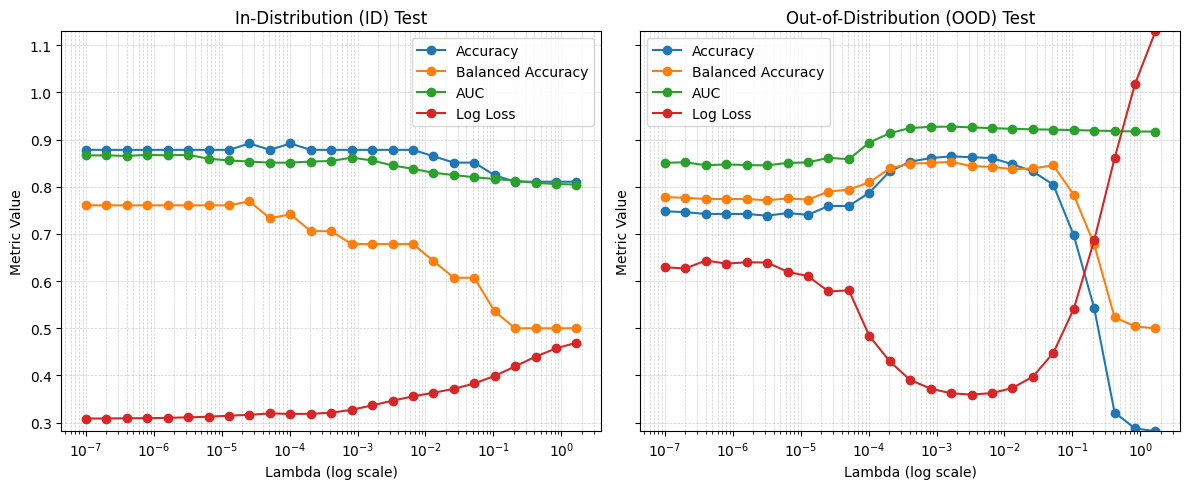

In [7]:
# Visualize the shift
x_train, y_train, x_test, y_test = split_id_ood(x_tot, y_tot)
X_id_tr, X_id_te, y_id_tr, y_id_te = train_test_split(x_train, y_train, test_size=0.2, stratify=y_train, random_state=0)

beta = 2
lbd_min, lbd_max = 1e-7, 1
m = int(np.ceil(np.log(lbd_max / lbd_min) / np.log(beta))) + 1
Lambda = lbd_min * (beta ** np.arange(m))
ml = len(Lambda)
n_1 = X_id_tr.shape[0]
Xl = np.arange(ml)
acc_list_id, auc_list_id, log_list_id, bal_acc_list_id = [], [], [], []
acc_list_ood, auc_list_ood, log_list_ood, bal_acc_list_ood = [], [], [], []

for lbd in Lambda:
    clf = LogisticRegression(max_iter=5000, C=1/(lbd*n_1)).fit(X_id_tr, y_id_tr)
    p_id_te = clf.predict_proba(X_id_te)[:, 1]
    p_ood = clf.predict_proba(x_test)[:, 1]

    print("\n=== Performance of ID-trained model ===")
    m_id = evaluate_binary(y_id_te, p_id_te, prefix="IDtest_")
    m_ood = evaluate_binary(y_test, p_ood, prefix="OOD_")
    pretty_print_metrics({**m_id, **m_ood})
    acc_list_id.append(m_id['IDtest_acc'])
    auc_list_id.append(m_id['IDtest_auc'])
    log_list_id.append(m_id['IDtest_logloss'])
    bal_acc_list_id.append(m_id['IDtest_bal_acc'])
    acc_list_ood.append(m_ood['OOD_acc'])
    auc_list_ood.append(m_ood['OOD_auc'])
    log_list_ood.append(m_ood['OOD_logloss'])
    bal_acc_list_ood.append(m_ood['OOD_bal_acc'])

# Prepare data for plotting
metrics_id = {
    'Accuracy': acc_list_id,
    'Balanced Accuracy': bal_acc_list_id,
    'AUC': auc_list_id,
    'Log Loss': log_list_id
}

metrics_ood = {
    'Accuracy': acc_list_ood,
    'Balanced Accuracy': bal_acc_list_ood,
    'AUC': auc_list_ood,
    'Log Loss': log_list_ood
}

metric_names = list(metrics_id.keys())
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

# Figure out the full y-range to align both axes
all_vals = []
for vals in metrics_id.values():
    all_vals.extend(vals)
for vals in metrics_ood.values():
    all_vals.extend(vals)
y_min = min(all_vals)
y_max = max(all_vals)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Plot ID metrics
ax = axes[0]
for metric, color in zip(metric_names, colors):
    ax.plot(Lambda, metrics_id[metric], marker='o', color=color, label=metric)
ax.set_xscale('log')
ax.set_xlabel('Lambda (log scale)')
ax.set_ylabel('Metric Value')
ax.set_title('In-Distribution (ID) Test')
ax.set_ylim([y_min, y_max])
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)

# Plot OOD metrics
ax = axes[1]
for metric, color in zip(metric_names, colors):
    ax.plot(Lambda, metrics_ood[metric], marker='o', color=color, label=metric)
ax.set_xscale('log')
ax.set_xlabel('Lambda (log scale)')
ax.set_ylabel('Metric Value')
ax.set_title('Out-of-Distribution (OOD) Test')
ax.set_ylim([y_min, y_max])
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)

fig.tight_layout()
plt.show()

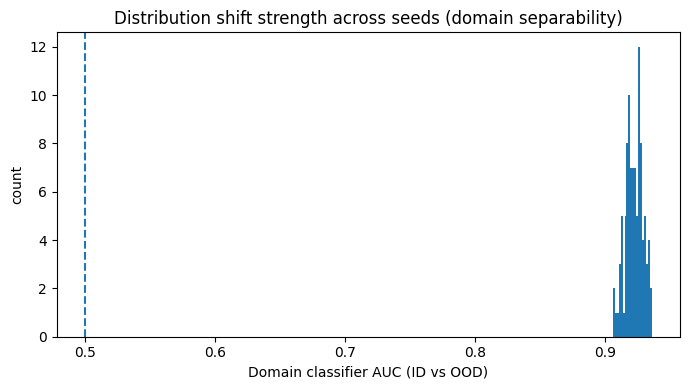

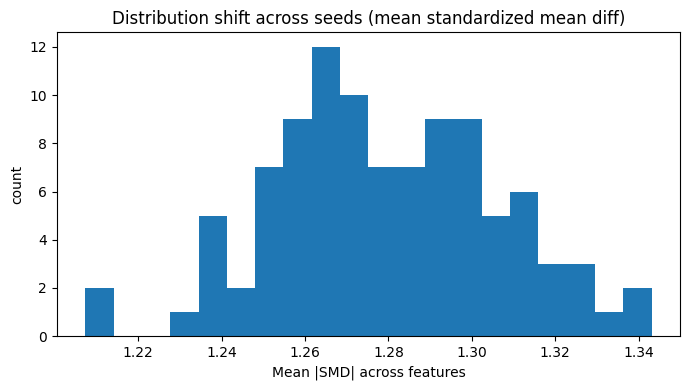

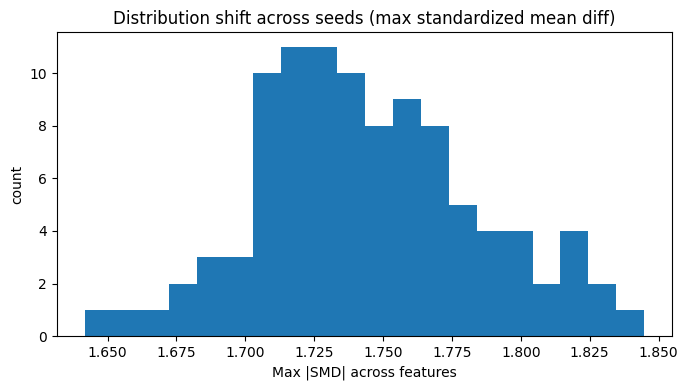

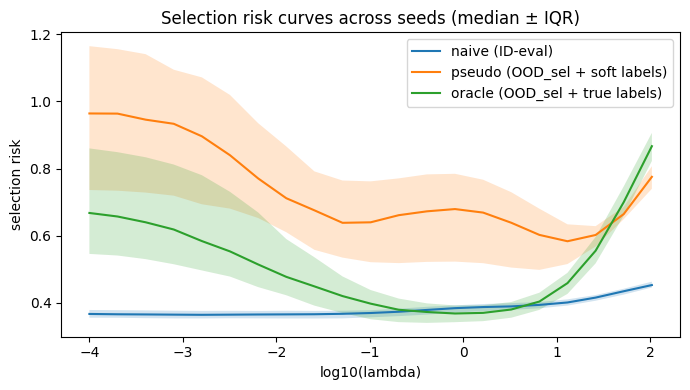

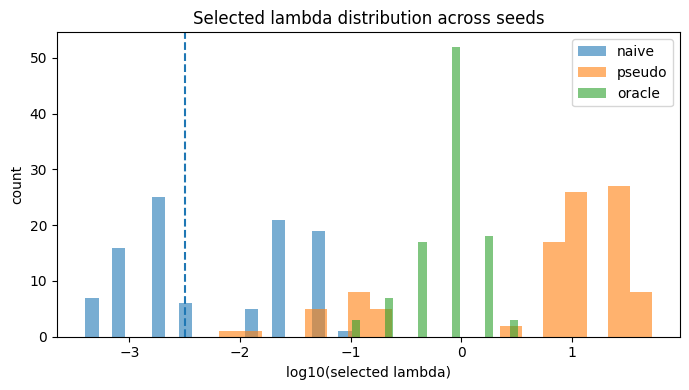


=== Per-method 'risk' across seeds: mean (95% CI) ===
 naive: 0.501901  CI[0.463215, 0.540586]  (SE=0.019497)
pseudo: 0.427850  CI[0.412162, 0.443537]  (SE=0.007906)
oracle: 0.372884  CI[0.360678, 0.385091]  (SE=0.006152)

=== risk: pseudo - naive (H1: pseudo better) ===
n_seeds = 100
mean(A-B) = -0.0740512   sd = 0.146583   se = 0.0146583
95% t-CI for mean: [-0.103136, -0.0449659]
t-test: t=-5.05182, p=1.00064e-06
Wilcoxon: W=1198, p=2.52551e-06
Sign test: wins/losses/ties = 62/38/0  p=0.0104894
Bootstrap CI (mean): [-0.104017, -0.0468683]  p=0

=== risk: oracle - naive (H1: oracle better) ===
n_seeds = 100
mean(A-B) = -0.129016   sd = 0.165328   se = 0.0165328
95% t-CI for mean: [-0.161821, -0.0962119]
t-test: t=-7.80368, p=3.15256e-12
Wilcoxon: W=216, p=1.01833e-15
Sign test: wins/losses/ties = 85/15/0  p=2.41271e-13
Bootstrap CI (mean): [-0.162709, -0.0991066]  p=0

=== risk: pseudo - oracle (H1: pseudo better) ===
n_seeds = 100
mean(A-B) = 0.0549653   sd = 0.0692391   se = 0.0069

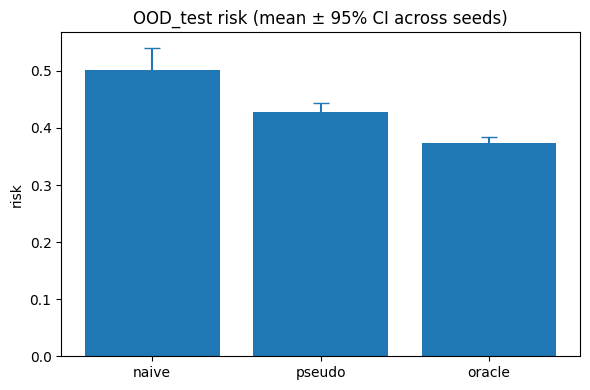

/var/folders/6j/c98hn3_j7qq3pvr0y_n23_vr0000gn/T/ipykernel_31631/3824428985.py:391: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([d_pn, d_on, d_po], labels=["pseudo-naive", "oracle-naive", "pseudo-oracle"], showfliers=True)


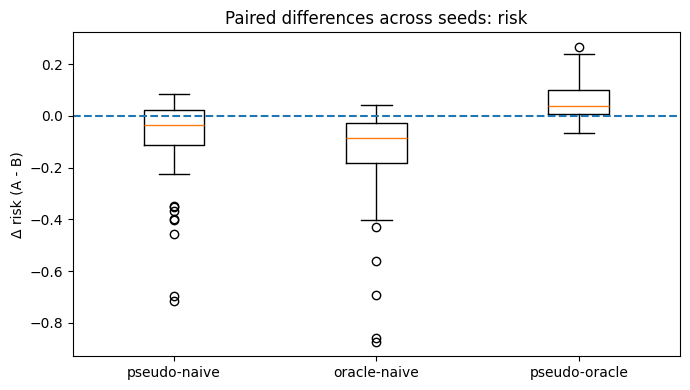

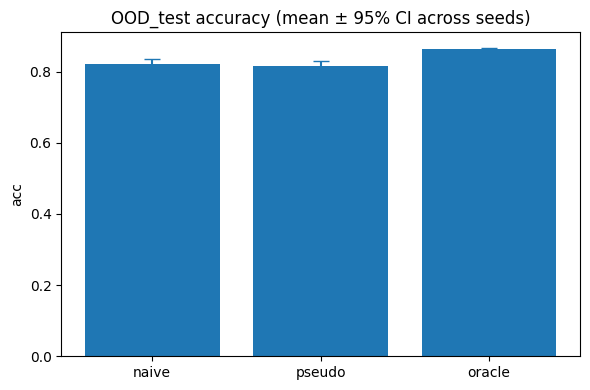

/var/folders/6j/c98hn3_j7qq3pvr0y_n23_vr0000gn/T/ipykernel_31631/3824428985.py:391: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([d_pn, d_on, d_po], labels=["pseudo-naive", "oracle-naive", "pseudo-oracle"], showfliers=True)


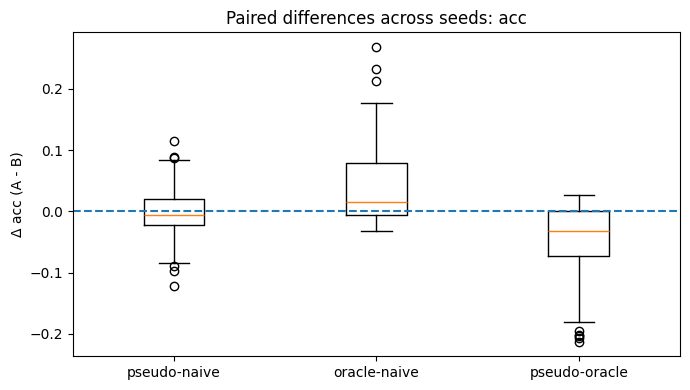


=== Best-in-grid regret on OOD_test (mean, 95% CI) ===
 regret_naive: 0.143945  CI[0.110638, 0.177252]  (SE=0.016786)
regret_pseudo: 0.069894  CI[0.057825, 0.081963]  (SE=0.006083)
regret_oracle: 0.014929  CI[0.010976, 0.018881]  (SE=0.001992)

Paired regret differences (lower is better):

=== regret: pseudo - naive ===
n_seeds = 100
mean(A-B) = -0.0740512   sd = 0.146583   se = 0.0146583
95% t-CI for mean: [-0.103136, -0.0449659]
t-test: t=-5.05182, p=1.00064e-06
Wilcoxon: W=1198, p=2.52551e-06
Sign test: wins/losses/ties = 62/38/0  p=0.0104894
Bootstrap CI (mean): [-0.104017, -0.0468683]  p=0

=== regret: oracle - naive ===
n_seeds = 100
mean(A-B) = -0.129016   sd = 0.165328   se = 0.0165328
95% t-CI for mean: [-0.161821, -0.0962119]
t-test: t=-7.80368, p=3.15256e-12
Wilcoxon: W=216, p=1.01833e-15
Sign test: wins/losses/ties = 85/15/0  p=2.41271e-13
Bootstrap CI (mean): [-0.163279, -0.0987047]  p=0

=== regret: pseudo - oracle ===
n_seeds = 100
mean(A-B) = 0.0549653   sd = 0.0692391

In [10]:
seeds = [i+100 for i in range(100)]

# imputer trained on small side, candidates on large side

fit_kwargs_practical = dict(
    mode="practical",   # optional; default is practical
    n_splits=2,
    repeats=6,
    beta=2.0,
    lbd_min=1e-4,
    lbd_max=100.0,
    lbd_tilde=1e-4,
    ood_test_frac=0.35,
    compute_auc=False,
)

fit_kwargs_theory = dict(
    mode="theory",
    id_holdout_frac=0.5,  # X2 size
    stratify_id=True,
    beta=2.0,
    lbd_min=1e-4,
    lbd_max=100.0,
    lbd_tilde=1e-4,
    ood_test_frac=0.35,
    compute_auc=False,
)

results = paper_report(
    x_tot=x_tot, y_tot=y_tot,
    seeds=seeds,
    split_id_ood=split_id_ood,
    family="logistic",
    fit_kwargs=fit_kwargs_practical,
    alpha=0.05,
    B=20000,
)

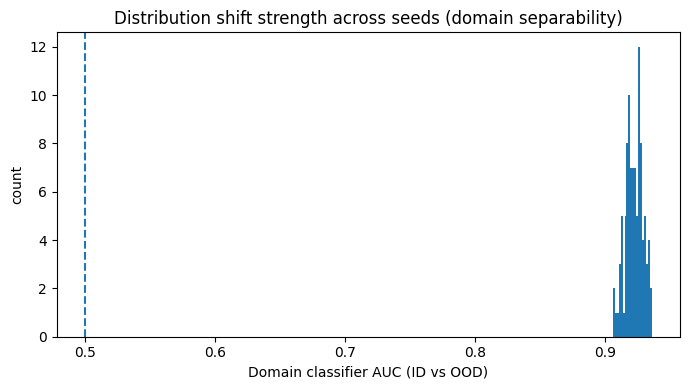

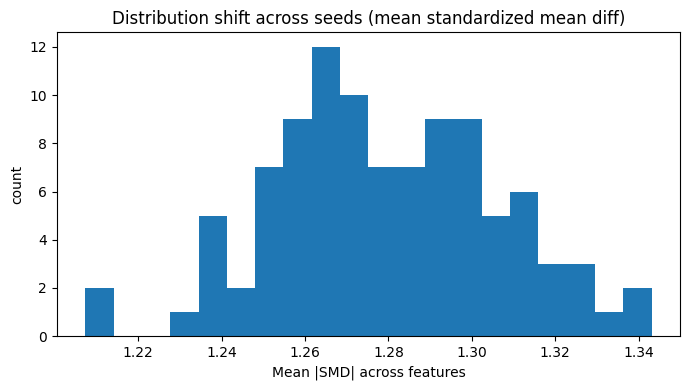

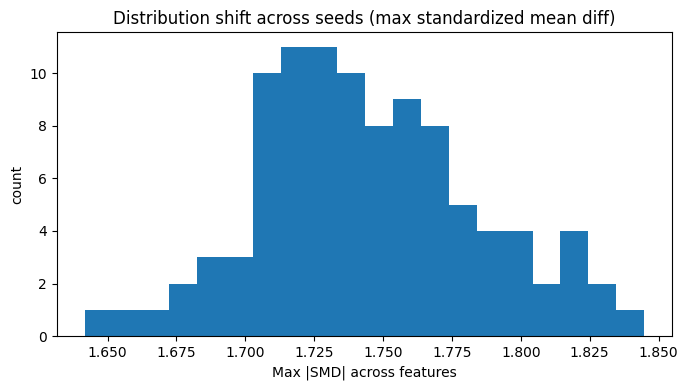

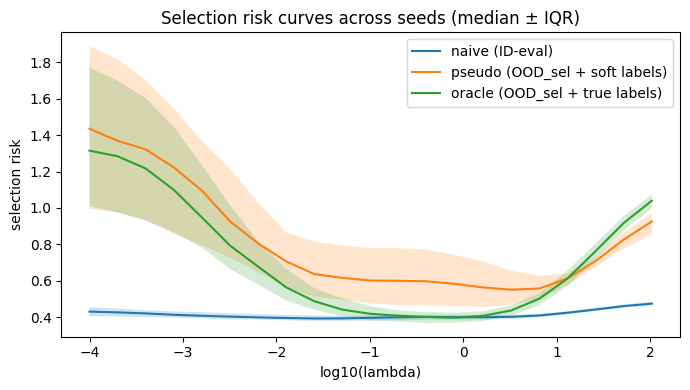

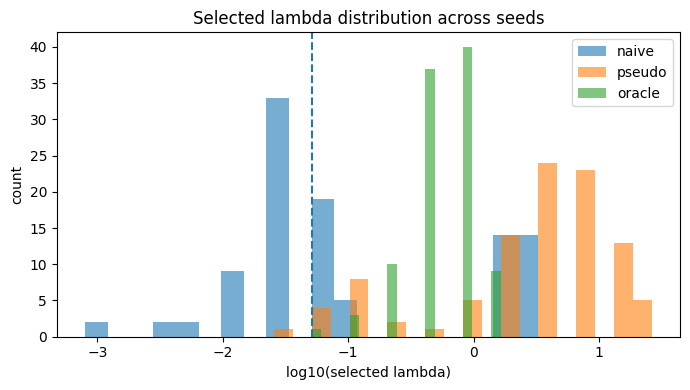


=== Per-method 'risk' across seeds: mean (95% CI) ===
 naive: 0.444060  CI[0.413993, 0.474127]  (SE=0.015153)
pseudo: 0.384502  CI[0.372975, 0.396028]  (SE=0.005809)
oracle: 0.376461  CI[0.363375, 0.389546]  (SE=0.006595)

=== risk: pseudo - naive (H1: pseudo better) ===
n_seeds = 100
mean(A-B) = -0.0595579   sd = 0.118328   se = 0.0118328
95% t-CI for mean: [-0.0830368, -0.036079]
t-test: t=-5.03328, p=1.08082e-06
Wilcoxon: W=935, p=4.97089e-07
Sign test: wins/losses/ties = 61/33/6  p=0.00253922
Bootstrap CI (mean): [-0.0840896, -0.038088]  p=0

=== risk: oracle - naive (H1: oracle better) ===
n_seeds = 100
mean(A-B) = -0.0675992   sd = 0.119478   se = 0.0119478
95% t-CI for mean: [-0.0913062, -0.0438921]
t-test: t=-5.65787, p=7.45942e-08
Wilcoxon: W=471, p=2.16574e-12
Sign test: wins/losses/ties = 77/21/2  p=5.44627e-09
Bootstrap CI (mean): [-0.0928321, -0.0461323]  p=0

=== risk: pseudo - oracle (H1: pseudo better) ===
n_seeds = 100
mean(A-B) = 0.00804125   sd = 0.0379848   se = 0.

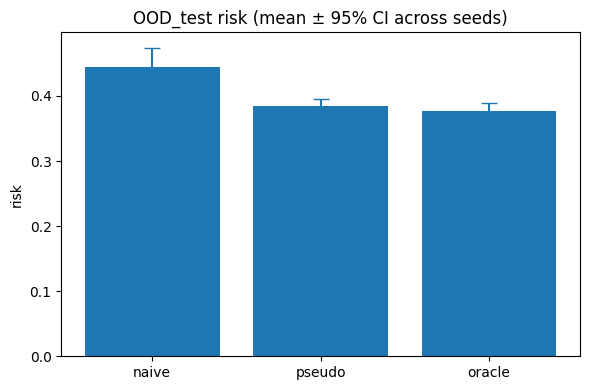

/var/folders/6j/c98hn3_j7qq3pvr0y_n23_vr0000gn/T/ipykernel_31631/3824428985.py:391: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([d_pn, d_on, d_po], labels=["pseudo-naive", "oracle-naive", "pseudo-oracle"], showfliers=True)


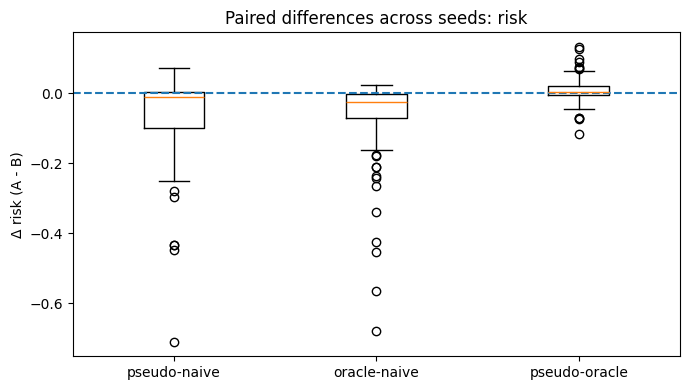

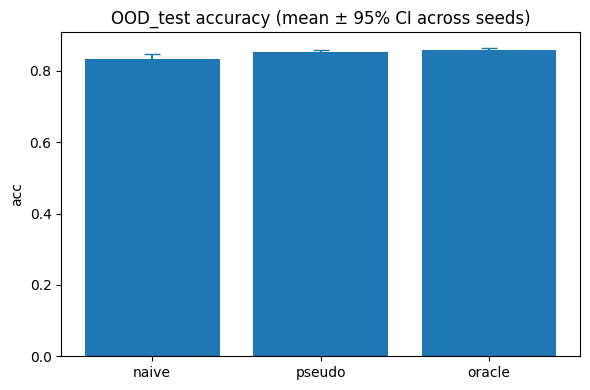

/var/folders/6j/c98hn3_j7qq3pvr0y_n23_vr0000gn/T/ipykernel_31631/3824428985.py:391: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([d_pn, d_on, d_po], labels=["pseudo-naive", "oracle-naive", "pseudo-oracle"], showfliers=True)


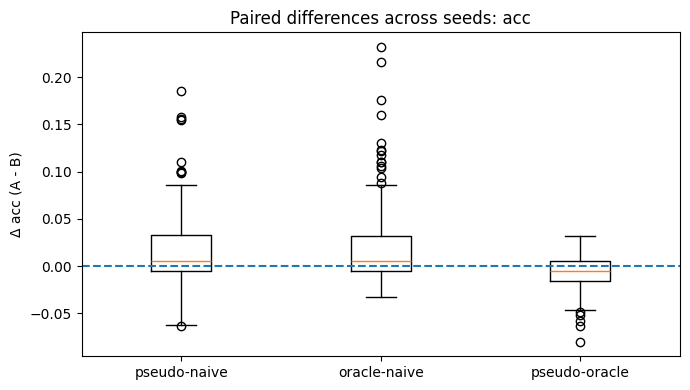


=== Best-in-grid regret on OOD_test (mean, 95% CI) ===
 regret_naive: 0.086104  CI[0.061071, 0.111137]  (SE=0.012616)
regret_pseudo: 0.026546  CI[0.020600, 0.032492]  (SE=0.002997)
regret_oracle: 0.018505  CI[0.013822, 0.023187]  (SE=0.002360)

Paired regret differences (lower is better):

=== regret: pseudo - naive ===
n_seeds = 100
mean(A-B) = -0.0595579   sd = 0.118328   se = 0.0118328
95% t-CI for mean: [-0.0830368, -0.036079]
t-test: t=-5.03328, p=1.08082e-06
Wilcoxon: W=935, p=4.97089e-07
Sign test: wins/losses/ties = 61/33/6  p=0.00253922
Bootstrap CI (mean): [-0.0840896, -0.038088]  p=0

=== regret: oracle - naive ===
n_seeds = 100
mean(A-B) = -0.0675992   sd = 0.119478   se = 0.0119478
95% t-CI for mean: [-0.0913062, -0.0438921]
t-test: t=-5.65787, p=7.45942e-08
Wilcoxon: W=471, p=2.16574e-12
Sign test: wins/losses/ties = 77/21/2  p=5.44627e-09
Bootstrap CI (mean): [-0.0923799, -0.0460435]  p=0

=== regret: pseudo - oracle ===
n_seeds = 100
mean(A-B) = 0.00804125   sd = 0.037

In [9]:
seeds = [i+100 for i in range(100)]

# imputer trained on small side, candidates on large side

fit_kwargs_practical = dict(
    mode="practical",   # optional; default is practical
    n_splits=5,
    repeats=1,
    beta=2.0,
    lbd_min=1e-4,
    lbd_max=100.0,
    lbd_tilde=1e-4,
    ood_test_frac=0.35,
    compute_auc=False,
)

fit_kwargs_theory = dict(
    mode="theory",
    id_holdout_frac=0.5,  # X2 size
    stratify_id=True,
    beta=2.0,
    lbd_min=1e-4,
    lbd_max=100.0,
    lbd_tilde=1e-4,
    ood_test_frac=0.35,
    compute_auc=False,
)

results = paper_report(
    x_tot=x_tot, y_tot=y_tot,
    seeds=seeds,
    split_id_ood=split_id_ood,
    family="logistic",
    fit_kwargs=fit_kwargs_practical,
    alpha=0.05,
    B=20000,
)